### imports

In [1]:
import pandas as pd 
import torch
import numpy as np

### data

In [2]:
from pathlib import Path
root=Path('data')
root.mkdir(exist_ok='True')
path1=root / 'csv1.csv'
path2=root / 'csv2.csv'

In [3]:
folder = Path("EEG_data")

rows = []

for file in sorted(folder.glob("*.csv")):
    data = np.loadtxt(file, delimiter=",")   # (1000,16)
    rows.append(data.tolist())               # keep full structure

# create DataFrame
df = pd.DataFrame({"eeg": rows})

# save nicely
df.to_csv("CSV1.csv", index=False)

CSV1 = np.loadtxt("CSV1.csv", dtype=str, delimiter=",")
CSV2 = np.loadtxt("CSV2.csv", dtype=str)

df = np.column_stack((CSV1, CSV2))

np.savetxt("df.csv", df, delimiter=",", fmt="%s")

In [4]:
samples = 40
rows, cols = 30000, 16

eeg_data = []
text_data = []

for i in range(samples):
    t = np.linspace(0, 1, rows)
    eeg = np.zeros((rows, cols))

    for ch in range(cols):
        freq = np.random.uniform(5, 20)

        # base sine
        signal = np.sin(2 * np.pi * freq * t)

        # create strong ON/OFF blocks (THIS makes pattern visible)
        mask = np.zeros(rows)
        for _ in range(5):  # 5 bursts
            start = np.random.randint(0, rows - 2000)
            mask[start:start+2000] = 1

        # apply bursts
        eeg[:, ch] = signal * mask

        # small noise
        eeg[:, ch] += 0.02 * np.random.randn(rows)

    eeg_data.append(eeg.tolist())
    text_data.append(f"sample_text_{i}")

df = pd.DataFrame({
    "eeg": eeg_data,
    "text": text_data
})


In [5]:
samples = 40
rows, cols = 30000, 16

eeg_data = []
text_data = []

for i in range(samples):
    eeg = np.random.rand(rows, cols)
    
    eeg_data.append(eeg.tolist())     # keep structure (no manual str)
    text_data.append(f"sample_text_{i}")

df = pd.DataFrame({
    "eeg": eeg_data,
    "text": text_data
})

df.to_csv("DF.csv", index=False)

In [6]:
df

,eeg,text
0,"[[0.8049563416555907, 0.6278202910319649, 0.39...",sample_text_0
1,"[[0.8815769581908317, 0.17196261373666877, 0.5...",sample_text_1
2,"[[0.364163049611543, 0.30928663226593855, 0.94...",sample_text_2
3,"[[0.9461319085299228, 0.5642874955927385, 0.35...",sample_text_3
4,"[[0.5136266182697282, 0.18659734019803487, 0.1...",sample_text_4
5,"[[0.691044228405469, 0.2062307889896665, 0.063...",sample_text_5
6,"[[0.2442217391945143, 0.4111649965572366, 0.53...",sample_text_6
7,"[[0.9598451961746511, 0.16825196115944718, 0.0...",sample_text_7
8,"[[0.8803750992836663, 0.9056939046426632, 0.16...",sample_text_8
9,"[[0.8734458954821067, 0.7630343295394801, 0.14...",sample_text_9


In [7]:
def eeg_to_spec_light(eeg, n_fft=128, hop_length=64):
    """
    eeg: (L,16)
    returns: (T, F, 16)
    """

    L, C = eeg.shape
    T = 1 + (L - n_fft) // hop_length
    F = n_fft // 2 + 1

    spec = np.empty((T, F, C), dtype=np.float32)

    for ch in range(C):
        signal = eeg[:, ch]

        frames = np.lib.stride_tricks.sliding_window_view(signal, n_fft)[::hop_length]  # (T, n_fft)

        window = np.hanning(n_fft)
        frames = frames * window

        fft = np.fft.rfft(frames, axis=1)     # (T, F)
        power = np.abs(fft) ** 2              # power

        log_spec = np.log(power + 1e-6)       # log

        spec[:, :, ch] = log_spec

    return spec  # (T, F, 16)

In [8]:
eeg_features = []

for x in df["eeg"]:
    eeg = np.asarray(x, dtype=np.float32)

    spec = eeg_to_spec_light(eeg)     # (T,F,16)
    spec = np.transpose(spec, (2,1,0))  # (16,F,T)

    eeg_features.append(spec)

df["eeg"] = eeg_features

In [9]:
df

,eeg,text
0,"[[[6.681572, 6.771182, 6.7085514, 6.8843083, 7...",sample_text_0
1,"[[[6.946327, 6.843621, 6.9516563, 7.0306115, 6...",sample_text_1
2,"[[[6.8715405, 6.9484973, 6.901465, 6.9764857, ...",sample_text_2
3,"[[[6.7903433, 6.787835, 6.9231014, 6.8417535, ...",sample_text_3
4,"[[[6.9499984, 6.8506827, 6.661844, 6.8310843, ...",sample_text_4
5,"[[[6.746462, 7.0126405, 6.9981813, 6.981449, 6...",sample_text_5
6,"[[[6.899412, 6.923885, 6.879947, 6.685975, 6.7...",sample_text_6
7,"[[[6.8520207, 6.7478604, 6.8286796, 6.781593, ...",sample_text_7
8,"[[[6.9243245, 6.8484054, 6.756849, 6.9321246, ...",sample_text_8
9,"[[[6.6855044, 6.937655, 6.962381, 6.864255, 6....",sample_text_9


In [10]:
df['text'][0]

'sample_text_0'

In [11]:
len(df['text'][0])

13

### data transformation

### Character Vocabulary

In [12]:
import string

chars = string.ascii_letters + string.digits + string.punctuation + " "
char2idx = {c: i+1 for i, c in enumerate(chars)}  # 0 reserved for padding
char2idx["<pad>"] = 0
char2idx["<eos>"] = len(char2idx)
char2idx["<bos>"] = len(char2idx) + 1
idx2char = {i: c for c, i in char2idx.items()}

vocab_size = len(char2idx) + 1
print("Vocab size:", vocab_size)

Vocab size: 99


In [13]:
char2idx

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 'A': 27,
 'B': 28,
 'C': 29,
 'D': 30,
 'E': 31,
 'F': 32,
 'G': 33,
 'H': 34,
 'I': 35,
 'J': 36,
 'K': 37,
 'L': 38,
 'M': 39,
 'N': 40,
 'O': 41,
 'P': 42,
 'Q': 43,
 'R': 44,
 'S': 45,
 'T': 46,
 'U': 47,
 'V': 48,
 'W': 49,
 'X': 50,
 'Y': 51,
 'Z': 52,
 '0': 53,
 '1': 54,
 '2': 55,
 '3': 56,
 '4': 57,
 '5': 58,
 '6': 59,
 '7': 60,
 '8': 61,
 '9': 62,
 '!': 63,
 '"': 64,
 '#': 65,
 '$': 66,
 '%': 67,
 '&': 68,
 "'": 69,
 '(': 70,
 ')': 71,
 '*': 72,
 '+': 73,
 ',': 74,
 '-': 75,
 '.': 76,
 '/': 77,
 ':': 78,
 ';': 79,
 '<': 80,
 '=': 81,
 '>': 82,
 '?': 83,
 '@': 84,
 '[': 85,
 '\\': 86,
 ']': 87,
 '^': 88,
 '_': 89,
 '`': 90,
 '{': 91,
 '|': 92,
 '}': 93,
 '~': 94,
 ' ': 95,
 '<pad>': 0,
 '<eos>': 96,
 '<bos>': 98}

In [14]:
idx2char

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 27: 'A',
 28: 'B',
 29: 'C',
 30: 'D',
 31: 'E',
 32: 'F',
 33: 'G',
 34: 'H',
 35: 'I',
 36: 'J',
 37: 'K',
 38: 'L',
 39: 'M',
 40: 'N',
 41: 'O',
 42: 'P',
 43: 'Q',
 44: 'R',
 45: 'S',
 46: 'T',
 47: 'U',
 48: 'V',
 49: 'W',
 50: 'X',
 51: 'Y',
 52: 'Z',
 53: '0',
 54: '1',
 55: '2',
 56: '3',
 57: '4',
 58: '5',
 59: '6',
 60: '7',
 61: '8',
 62: '9',
 63: '!',
 64: '"',
 65: '#',
 66: '$',
 67: '%',
 68: '&',
 69: "'",
 70: '(',
 71: ')',
 72: '*',
 73: '+',
 74: ',',
 75: '-',
 76: '.',
 77: '/',
 78: ':',
 79: ';',
 80: '<',
 81: '=',
 82: '>',
 83: '?',
 84: '@',
 85: '[',
 86: '\\',
 87: ']',
 88: '^',
 89: '_',
 90: '`',
 91: '{',
 92: '|',
 93: '}',
 94: '~',
 95: ' ',
 0: '<pad>',
 96: '<eos>',
 98: '<bos>'}

### Text Encoding Function

In [15]:
max_len = max(map(len, df["text"]))
print("Max length:", max_len)

Max length: 14


In [16]:
def encode_text(text, max_len=30):
    # reserve space for BOS and EOS
    text = text[:max_len - 2]

    tokens = [char2idx["<bos>"]]
    tokens += [char2idx.get(c, 0) for c in text]
    tokens.append(char2idx["<eos>"])

    return tokens

In [17]:
def decode(tokens):
    text = ""
    for t in tokens:
        if t == char2idx["<eos>"]:
            break
        if t in idx2char:
            ch = idx2char[t]
            if ch not in ["<bos>", "<pad>"]:
                text += ch
    return text

In [18]:
x= 'i am unknown'
x

'i am unknown'

In [19]:
x[:128-1]

'i am unknown'

In [20]:
x[1:]

' am unknown'

In [21]:
x = encode_text('i am unknown')
print(x)
print(len(x))

[98, 9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14, 96]
14


In [22]:
decode([98, 9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14, 96, 0, 0])

'i am unknown'

In [23]:
PAD = char2idx["<pad>"]
BOS = char2idx["<bos>"]

new_rows = []

for _, row in df.iterrows():
    eeg = row["eeg"]
    text = row["text"]

    encoded = [char2idx[c] for c in text]

    # progressive sequences (no padding)
    for i in range(1, len(encoded) + 1):
        seq = [BOS] + encoded[:i]

        new_rows.append({
            "eeg": eeg,
            "text": seq
        })

df_new = pd.DataFrame(new_rows)

In [24]:
df_new

,eeg,text
0,"[[[6.681572, 6.771182, 6.7085514, 6.8843083, 7...","[98, 19]"
1,"[[[6.681572, 6.771182, 6.7085514, 6.8843083, 7...","[98, 19, 1]"
2,"[[[6.681572, 6.771182, 6.7085514, 6.8843083, 7...","[98, 19, 1, 13]"
3,"[[[6.681572, 6.771182, 6.7085514, 6.8843083, 7...","[98, 19, 1, 13, 16]"
4,"[[[6.681572, 6.771182, 6.7085514, 6.8843083, 7...","[98, 19, 1, 13, 16, 12]"
...,...,...
545,"[[[7.0753517, 7.1128597, 6.935231, 6.81594, 7....","[98, 19, 1, 13, 16, 12, 5, 89, 20, 5, 24]"
546,"[[[7.0753517, 7.1128597, 6.935231, 6.81594, 7....","[98, 19, 1, 13, 16, 12, 5, 89, 20, 5, 24, 20]"
547,"[[[7.0753517, 7.1128597, 6.935231, 6.81594, 7....","[98, 19, 1, 13, 16, 12, 5, 89, 20, 5, 24, 20, 89]"
548,"[[[7.0753517, 7.1128597, 6.935231, 6.81594, 7....","[98, 19, 1, 13, 16, 12, 5, 89, 20, 5, 24, 20, ..."


In [25]:
def rawdecode(tokens):
    text = ""
    for t in tokens:
        if t in idx2char:
            ch = idx2char[t]
            text += ch
    return text

In [37]:
for i in range(18):
    seq = df_new["text"].iloc[i]

    input_ids = seq[:-1]
    labels    = seq[1:]

    print("INPUT :", rawdecode(input_ids))
    print("LABEL :", rawdecode(labels))

INPUT : <bos>
LABEL : s
INPUT : <bos>s
LABEL : sa
INPUT : <bos>sa
LABEL : sam
INPUT : <bos>sam
LABEL : samp
INPUT : <bos>samp
LABEL : sampl
INPUT : <bos>sampl
LABEL : sample
INPUT : <bos>sample
LABEL : sample_
INPUT : <bos>sample_
LABEL : sample_t
INPUT : <bos>sample_t
LABEL : sample_te
INPUT : <bos>sample_te
LABEL : sample_tex
INPUT : <bos>sample_tex
LABEL : sample_text
INPUT : <bos>sample_text
LABEL : sample_text_
INPUT : <bos>sample_text_
LABEL : sample_text_0
INPUT : <bos>
LABEL : s
INPUT : <bos>s
LABEL : sa
INPUT : <bos>sa
LABEL : sam
INPUT : <bos>sam
LABEL : samp
INPUT : <bos>samp
LABEL : sampl


In [27]:
for i in range(13):
    print(rawdecode(df_new["text"].iloc[i]))

<bos>s
<bos>sa
<bos>sam
<bos>samp
<bos>sampl
<bos>sample
<bos>sample_
<bos>sample_t
<bos>sample_te
<bos>sample_tex
<bos>sample_text
<bos>sample_text_
<bos>sample_text_0


In [28]:
print(x[:-1])
print(len(x[:-1]))

[98, 9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14]
13


In [29]:
print(x[1:])
print(len(x[1:]))

[9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14, 96]
13


In [30]:
print(x[:-1])
print(x[1:])

[98, 9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14]
[9, 95, 1, 13, 95, 21, 14, 11, 14, 15, 23, 14, 96]


### PyTorch Dataset Class

In [31]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [32]:
def encode_text(text, max_len=30):
    text = text[:max_len-2]  # reserve space for <bos> and <eos>
    
    tokens = [char2idx["<bos>"]] + [char2idx.get(c, 0) for c in text]
    tokens.append(char2idx["<eos>"])
    
    if len(tokens) < max_len:
        tokens += [0] * (max_len - len(tokens))
    
    return tokens

In [39]:
class BSRDataset(Dataset):
    def __init__(self, dataset, max_len=16):
        self.data = dataset
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data.iloc[idx] 

        image = sample["eeg"]
        text = sample["text"]

        tokens = encode_text(text, self.max_len)

        return {
            "image": image,                      # (16, 64, 256)
            "input_ids": torch.tensor(tokens[:-1]),  # input
            "labels": torch.tensor(tokens[1:])       # target
        }

### Create Dataset + Check

In [40]:
train_dataset = BSRDataset(df_new)

In [41]:
sample = train_dataset[0]
print("Image shape:", sample["image"].shape)
print("Input IDs shape:", sample["input_ids"].shape)
print("Labels shape:", sample["labels"].shape)

Image shape: (16, 65, 467)
Input IDs shape: torch.Size([15])
Labels shape: torch.Size([15])


### DataLoader

In [42]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

batch = next(iter(train_loader))

print(batch["image"].shape)      # (B, 16, 65, 467)
print(batch["input_ids"].shape)  # (B, T)
print(batch["labels"].shape)     # (B, T)

torch.Size([8, 16, 65, 467])
torch.Size([8, 15])
torch.Size([8, 15])


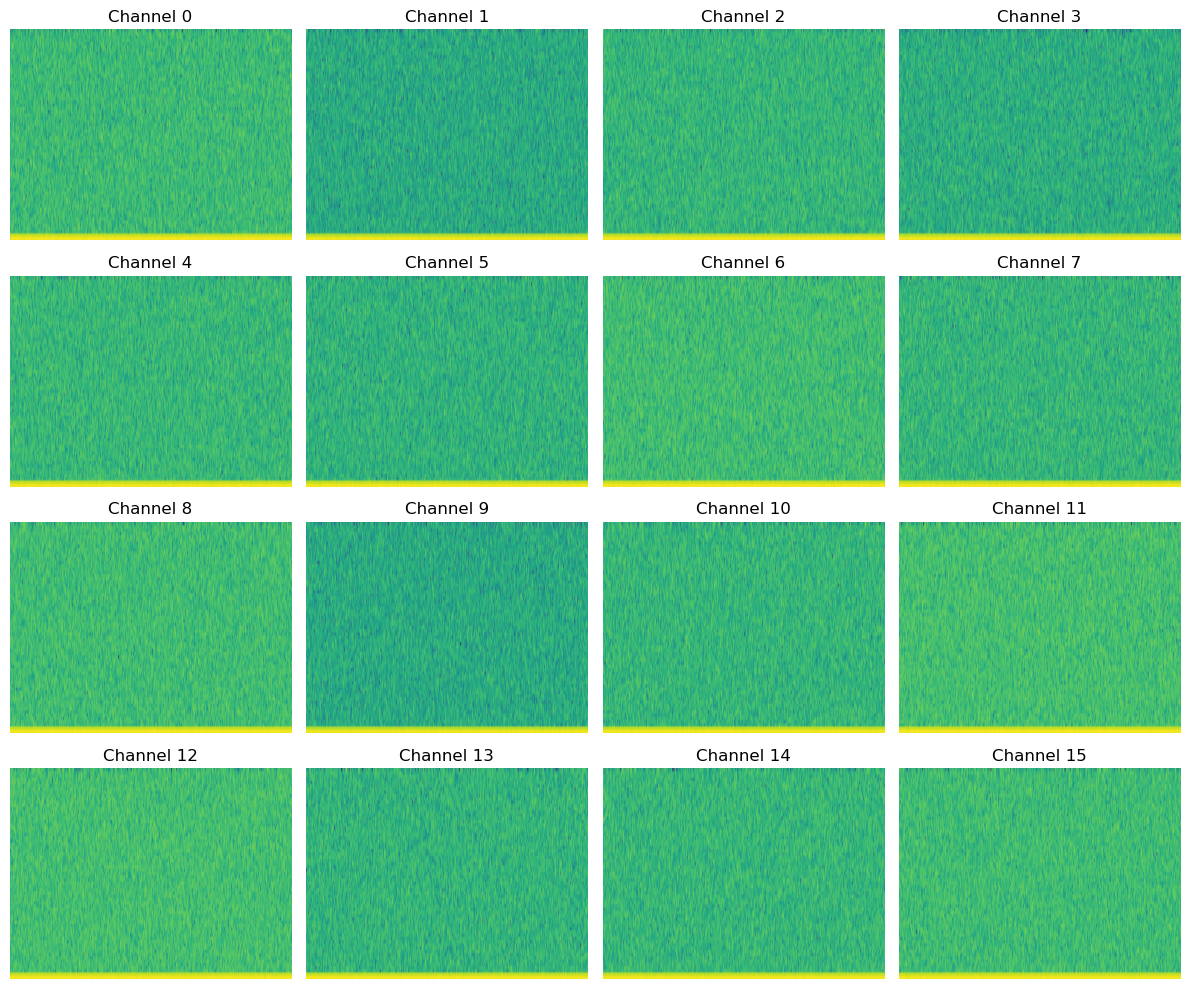

In [43]:
import matplotlib.pyplot as plt

eeg = df["eeg"][0]  # (16, F, T)

fig, axes = plt.subplots(4, 4, figsize=(12, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(eeg[i], aspect='auto', origin='lower')
    ax.set_title(f'Channel {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()

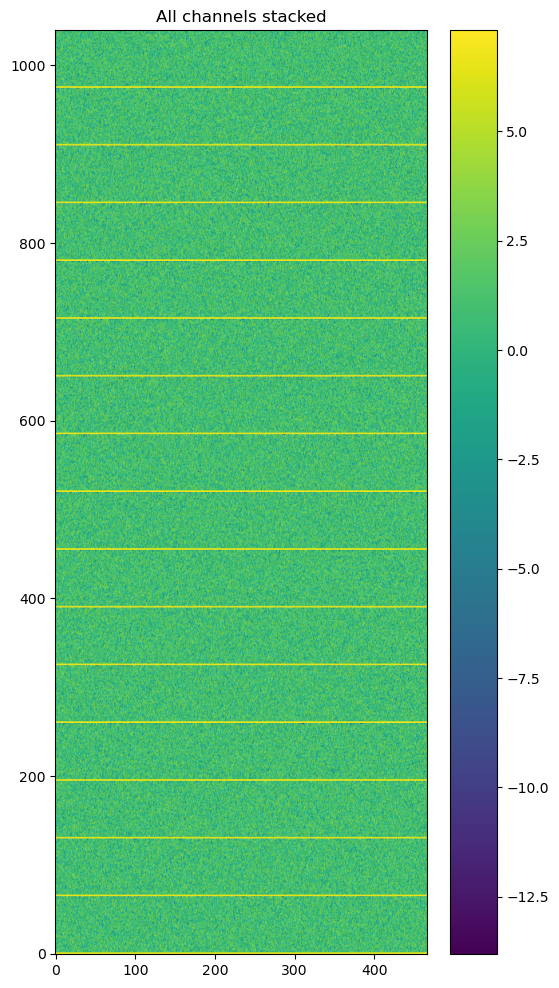

In [44]:
plt.figure(figsize=(6, 12))

stacked = eeg.reshape(16 * eeg.shape[1], eeg.shape[2])  # (16*F, T)

plt.imshow(stacked, aspect='auto', origin='lower')
plt.title("All channels stacked")
plt.colorbar()
plt.show()

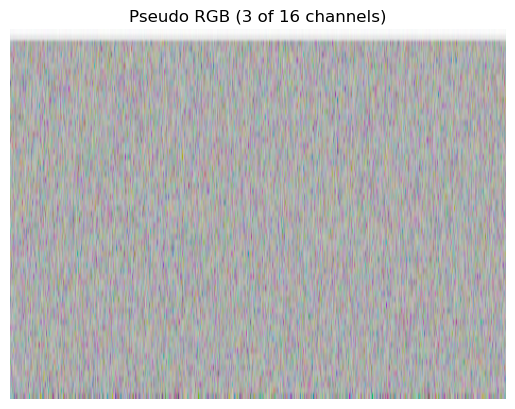

In [45]:
import numpy as np
import matplotlib.pyplot as plt

eeg = df["eeg"][0]  # (16, F, T)

rgb = np.stack([eeg[0], eeg[1], eeg[2]], axis=-1)  # (F, T, 3)

# normalize to 0–1
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb, aspect='auto')
plt.title("Pseudo RGB (3 of 16 channels)")
plt.axis('off')
plt.show()

# Transfomer Architecture

Image:
→ PatchEmbed → Pos → confomer → image_tokens (B, 6, 360)

Text:
→ Embedding → Pos → text_tokens (B, 127, 360)

Decoder:
→ Masked Self-Attn (text)
→ Cross-Attn (text ↔ image)
→ FF

Output:
→ Linear → vocab

In [46]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import math

### Patch Embedding Module

In [47]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=16, d_model=360):
        super().__init__()
        
        self.proj = nn.Sequential(
            # (B, 16, F, T)
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=2, padding=1),   # → (B, 64, F/2, T/2)
            nn.GELU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),           # → (B, 128, F/4, T/4)
            nn.GELU(),
            
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),          # → (B, 256, F/8, T/8)
            nn.GELU(),
            
            nn.Conv2d(256, d_model, kernel_size=3, stride=2, padding=1),      # → (B, 360, F/16, T/16)
        )

    def forward(self, x):
        """
        x: (B, 16, F, T)
        """
        x = self.proj(x)                     # (B, 360, H, W)
        
        B, C, H, W = x.shape
        x = x.flatten(2)                    # (B, 360, H*W)
        x = x.transpose(1, 2)               # (B, H*W, 360)
        
        return x

In [48]:
x = torch.randn(2, 16, 65, 467)

patch_embed = PatchEmbedding()

out = patch_embed(x)

print("Output shape:", out.shape)

Output shape: torch.Size([2, 150, 360])


### ImagePositionalEmbedding

In [49]:
class ImagePositionalEmbedding(nn.Module):
    def __init__(self, num_patches=150, d_model=360):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, d_model))

    def forward(self, x):
        """
        x: (B, 150, 360)
        """
        return x + self.pos_embed

In [50]:
x = torch.randn(2, 150, 360)

pos = ImagePositionalEmbedding()

out = pos(x)

print(out.shape)

torch.Size([2, 150, 360])


### TextEmbedding + PositionalEmbedding

In [51]:
class TextPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, embdim, max_len=512):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embdim, padding_idx=0)

        pe = torch.zeros(max_len, embdim)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embdim, 2) * (-math.log(10000.0) / embdim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))  # (1, T, D)

    def forward(self, x):
        B, T = x.size()
        emb = self.embedding(x)                      # (B, T, D)
        emb = emb + self.pe[:, :T, :]                # (B, T, D)
        return emb

In [52]:
x = torch.randint(1, 50, (2, 18))
model = TextPositionalEmbedding(vocab_size=100, embdim=360, max_len=512)
out = model(x)
print(x)
print("Input shape:", x.shape)      # (2, 10)
print("Output shape:", out.shape)   # (2, 10, 360)

tensor([[28, 25, 43, 37, 20, 48, 42, 31,  6, 40, 32, 38, 38,  5, 40, 20, 27, 49],
        [47, 48, 36, 33, 22, 21,  1, 19, 10, 27,  3, 38, 35, 21, 35, 29, 28, 43]])
Input shape: torch.Size([2, 18])
Output shape: torch.Size([2, 18, 360])


In [53]:
import matplotlib.pyplot as plt

In [54]:
def plot_pos(max_len = 300 ,embdim = 60,cmap='Spectral'):

    # build PE from formula
    pe = torch.zeros(max_len, embdim)
    position = torch.arange(0, max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, embdim, 2) * (-math.log(10000.0) / embdim)
    )
    
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    
    # plot
    plt.figure(figsize=(18, 8))
    plt.imshow(pe.T, aspect="auto", cmap=cmap)
    plt.colorbar(label="PE value")
    plt.xlabel("Position")
    plt.ylabel("Embedding dimension")
    plt.title("Sinusoidal Positional Encoding ")
    plt.show()


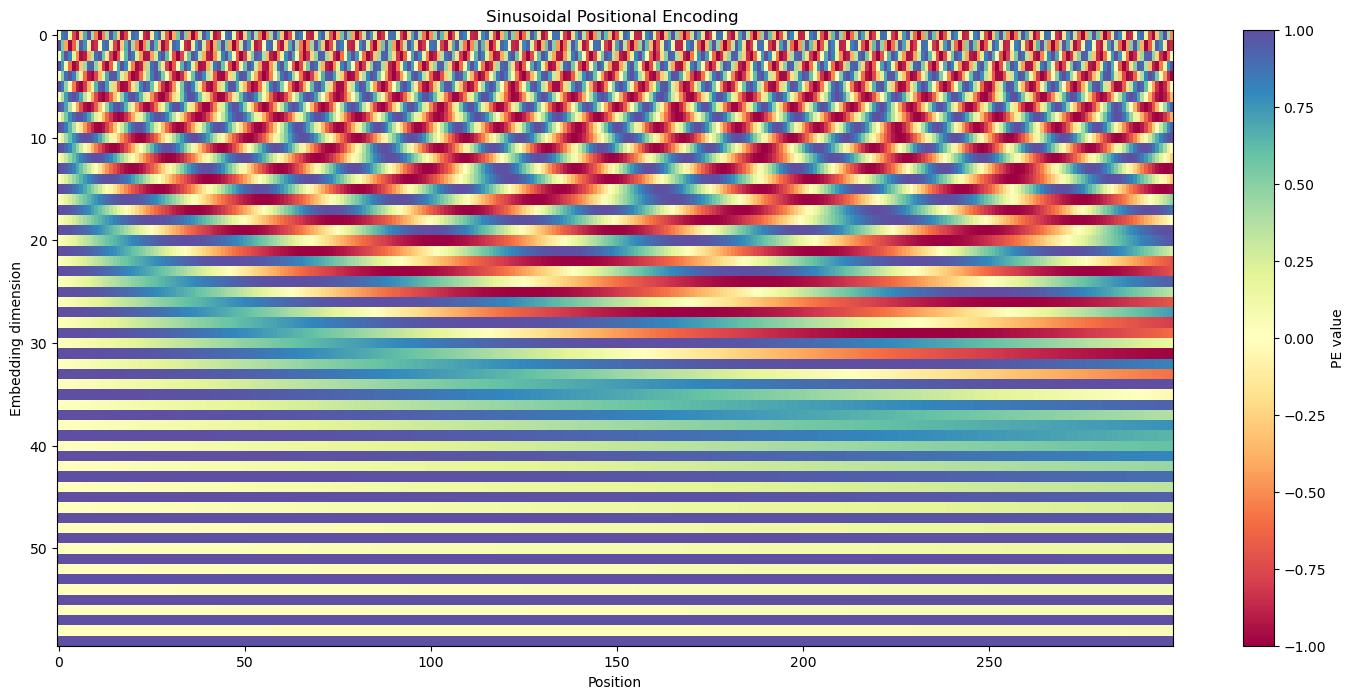

In [55]:
plot_pos()

## Conformer Encoder Architecture

### ConformerConvModule

In [56]:
class ConformerConvModule(nn.Module):
    def __init__(self, d_model, expansion_factor=2, kernel_size=31, dropout=0.1):
        super().__init__()

        inner_dim = d_model * expansion_factor

        self.layer_norm = nn.LayerNorm(d_model)

        self.pointwise_conv1 = nn.Conv1d(d_model, inner_dim * 2, kernel_size=1)
        self.glu = nn.GLU(dim=1)

        self.depthwise_conv = nn.Conv1d(
            inner_dim,
            inner_dim,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=inner_dim
        )

        self.batch_norm = nn.BatchNorm1d(inner_dim)
        self.slu = nn.SiLU()

        self.pointwise_conv2 = nn.Conv1d(inner_dim, d_model, kernel_size=1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        x = self.layer_norm(x)

        x = x.transpose(1, 2)   # → (B, D, T)

        x = self.pointwise_conv1(x)   # → (B, 2*inner, T)
        x = self.glu(x)               # → (B, inner, T)

        x = self.depthwise_conv(x)    # → (B, inner, T)
        x = self.batch_norm(x)
        x = self.slu(x)

        x = self.pointwise_conv2(x)   # → (B, D, T)

        x = x.transpose(1, 2)         # → (B, T, D)

        return self.dropout(x)

### Multi-head-attention

In [57]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        B, T, D = x.shape

        qkv = self.qkv(x)  # (B, T, 3D)
        qkv = qkv.view(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        Q, K, V = qkv[0], qkv[1], qkv[2]

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### Feed-Forward Network

In [58]:
class FeedForwardModule(nn.Module):
    def __init__(self, d_model, expansion_factor=4, dropout=0.1):
        super().__init__()

        inner_dim = d_model * expansion_factor

        self.net = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, inner_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(inner_dim, d_model),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

### ConformerBlock

In [59]:
class ConformerBlock(nn.Module):
    def __init__(self, d_model=360, num_heads=6, ff_expansion=4, conv_expansion=2, dropout=0.1):
        super().__init__()

        self.ff1 = FeedForwardModule(d_model, ff_expansion, dropout)
        self.mha = MultiHeadAttention(d_model, num_heads, dropout)
        self.conv = ConformerConvModule(d_model, conv_expansion, dropout=dropout)
        self.ff2 = FeedForwardModule(d_model, ff_expansion, dropout)

        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        # Macaron FFN (half step)
        x = x + 0.5 * self.ff1(x)

        # MHSA
        x = x + self.mha(x)

        # Conv module
        x = x + self.conv(x)

        # Second FFN
        x = x + 0.5 * self.ff2(x)

        # Final norm
        x = self.norm(x)

        return x

### Conformer

In [60]:
class ConformerEncoder(nn.Module):
    def __init__(self, num_layers=6, d_model=360, num_heads=8):
        super().__init__()

        self.layers = nn.ModuleList([
            ConformerBlock(d_model=d_model, num_heads=num_heads)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        """
        x: (B, T, D)
        """

        for layer in self.layers:
            x = layer(x)

        return x

In [61]:
import torch.nn.functional as F

In [62]:
x = torch.randn(2, 16, 65, 467)

# modules
patch = PatchEmbedding(d_model=360)
pos = ImagePositionalEmbedding(d_model=360)
encoder = ConformerEncoder(num_layers=6, d_model=360, num_heads=6)

# forward
out = patch(x)      
out = pos(out)      
out = encoder(out)  

print("Input shape :", x.shape)
print("After patch :", out.shape)

Input shape : torch.Size([2, 16, 65, 467])
After patch : torch.Size([2, 150, 360])


## DECODER Architecture

### MaskedMultiHeadAttention

In [63]:
class MaskedMultiHeadAttention(nn.Module):
    def __init__(self, embdim, num_heads, dropout=0.1):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = embdim // num_heads

        self.Wq = nn.Linear(embdim, embdim)
        self.Wk = nn.Linear(embdim, embdim)
        self.Wv = nn.Linear(embdim, embdim)

        self.out = nn.Linear(embdim, embdim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: (B, T, D)
        """

        B, T, D = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # → (B, heads, T, T)

        # CAUSAL MASK
        mask = torch.tril(torch.ones(T, T, device=x.device)).bool()
        mask = mask.unsqueeze(0).unsqueeze(0)  # → (1,1,T,T)

        scores = scores.masked_fill(~mask, float('-inf'))

        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        out = torch.matmul(weights, V)
        # → (B, heads, T, head_dim)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### CrossAttention

In [64]:
class CrossAttention(nn.Module):
    def __init__(self, embdim, num_heads, dropout=0.1):
        super().__init__()

        self.num_heads = num_heads
        self.head_dim = embdim // num_heads

        self.Wq = nn.Linear(embdim, embdim)
        self.Wk = nn.Linear(embdim, embdim)
        self.Wv = nn.Linear(embdim, embdim)

        self.out = nn.Linear(embdim, embdim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, query, context):
        """
        query:   (B, T, D) → text
        context: (B, N, D) → image
        """

        B, T, D = query.shape
        N = context.shape[1]

        Q = self.Wq(query)
        K = self.Wk(context)
        V = self.Wv(context)

        Q = Q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # → (B, heads, T, N)

        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        out = torch.matmul(weights, V)
        # → (B, heads, T, head_dim)

        out = out.transpose(1, 2).contiguous().view(B, T, D)

        return self.out(out)

### FeedForward

In [65]:
class FeedForward(nn.Module):
    def __init__(self, embdim, hidden_dim, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(embdim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embdim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        """
        x: (B, T, D)
        """
        return self.net(x)

### DecoderBlock

In [66]:
class DecoderBlock(nn.Module):
    def __init__(self, embdim, num_heads, ff_hidden_dim, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embdim)
        self.norm2 = nn.LayerNorm(embdim)
        self.norm3 = nn.LayerNorm(embdim)

        self.self_attn = MaskedMultiHeadAttention(embdim, num_heads, dropout)
        self.cross_attn = CrossAttention(embdim, num_heads, dropout)
        self.ff = FeedForward(embdim, ff_hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, text_tokens, audio_tokens):
        """
        text_tokens:  (B, T, D)
        audio_tokens: (B, N, D)
        """

        # 1. Masked Self Attention
        x = text_tokens + self.dropout(
            self.self_attn(self.norm1(text_tokens))
        )

        # 2. Cross Attention (text ↔ audio)
        x = x + self.dropout(
            self.cross_attn(self.norm2(x), audio_tokens)
        )

        # 3. Feed Forward
        x = x + self.dropout(
            self.ff(self.norm3(x))
        )

        return x

### Decoder

In [67]:
class Decoder(nn.Module):
    def __init__(self, depth, embdim, num_heads, ff_hidden_dim):
        super().__init__()

        self.layers = nn.ModuleList([
            DecoderBlock(embdim, num_heads, ff_hidden_dim)
            for _ in range(depth)
        ])

    def forward(self, text_tokens, audio_tokens):
        """
        text_tokens:  (B, T, D)
        audio_tokens: (B, N, D)
        """

        for layer in self.layers:
            text_tokens = layer(text_tokens, audio_tokens)

        return text_tokens

In [68]:
# Dummy inputs
text = torch.randn(2, 18, 360)     # decoder input
audio = torch.randn(2, 150, 360)   # encoder output

decoder = Decoder(
    depth=2,
    embdim=360,
    num_heads=6,
    ff_hidden_dim=2048
)

out = decoder(text, audio)

print("Text input shape :", text.shape)
print("Audio input shape:", audio.shape)
print("Output shape     :", out.shape)

Text input shape : torch.Size([2, 18, 360])
Audio input shape: torch.Size([2, 150, 360])
Output shape     : torch.Size([2, 18, 360])


## Vocab Head

In [69]:
class VocabHead(nn.Module):
    def __init__(self, embdim, vocab_size):
        super().__init__()
        self.proj = nn.Linear(embdim, vocab_size)

    def forward(self, x):
        """
        x: (B, T, D)
        """
        return self.proj(x)   # (B, T, vocab_size)

In [70]:
B, T, D = 2, 18, 360
vocab_size = 100

x = torch.randn(B, T, D)

head = VocabHead(D, vocab_size)

out = head(x)

print("Output shape:", out.shape)

Output shape: torch.Size([2, 18, 100])


# TRANSFORMER MODEL

In [71]:
class BSRTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=360,
        encoder_layers=6,
        decoder_layers=6,
        num_heads=6,
        ff_expansion=3,
        conv_expansion=2,
        ff_hidden_dim=2048,
        max_text_len=518,
        dropout=0.1
    ):
        super().__init__()

        # Audio patch embedding + positional embedding
        self.patch_embed = PatchEmbedding(d_model=d_model)
        self.audio_pos = ImagePositionalEmbedding(d_model=d_model)

        # Conformer encoder
        self.encoder = ConformerEncoder(num_layers=encoder_layers, d_model=d_model, num_heads=num_heads)

        # Text embedding + positional embedding
        self.text_pos = TextPositionalEmbedding(vocab_size=vocab_size, embdim=d_model, max_len=max_text_len,)

        # Decoder
        self.decoder = Decoder(depth=decoder_layers, embdim=d_model, num_heads=num_heads, ff_hidden_dim=ff_hidden_dim)

        # Output head
        self.vocab_head = VocabHead(d_model, vocab_size)

    def forward(self, audio, text):
        """
        audio: (B, T_audio, F)  → waveform/spectrogram
        text:  (B, T_text)       → decoder input tokens
        """

        # 1. Encoder
        audio_tokens = self.patch_embed(audio)        # (B, N_audio, D)
        audio_tokens = self.audio_pos(audio_tokens)   # (B, N_audio, D)
        enc_out = self.encoder(audio_tokens)          # (B, N_audio, D)

        # 2. Decoder
        text_tokens = self.text_pos(text)            # (B, T_text, D)
        dec_out = self.decoder(text_tokens, enc_out) # (B, T_text, D)

        # 3. Output logits
        logits = self.vocab_head(dec_out)            # (B, T_text, vocab_size)

        return logits

In [72]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [73]:
my_model=BSRTransformer(
    vocab_size=100,
    d_model=360,
    encoder_layers=6,
    decoder_layers=6,
    num_heads=6,
    ff_hidden_dim=2048,
    max_text_len=16,
    dropout=0.1
)
my_model

BSRTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Sequential(
      (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): GELU(approximate='none')
      (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (5): GELU(approximate='none')
      (6): Conv2d(256, 360, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
  )
  (audio_pos): ImagePositionalEmbedding()
  (encoder): ConformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x ConformerBlock(
        (ff1): FeedForwardModule(
          (net): Sequential(
            (0): LayerNorm((360,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=360, out_features=1440, bias=True)
            (2): GELU(approximate='none')
            (3): Dropout(p=0.1, inplace=False)
            (4): Linear(in_features=1440, out_features=360, bias=True)

In [74]:
B = 2
image = torch.randn(B, 16, 65, 467)
text = torch.randint(0, 99, (B, 16))  # including PAD=0

model = BSRTransformer(vocab_size=99)

out = model(image, text)
print("image shape:",image.shape)
print("text shape:",text.shape)
print("Output shape:", out.shape)

image shape: torch.Size([2, 16, 65, 467])
text shape: torch.Size([2, 16])
Output shape: torch.Size([2, 16, 99])


In [75]:
out

tensor([[[ 7.1250e-01,  1.0120e+00,  7.2229e-01,  ...,  1.1972e-01,
           1.8275e+00, -2.1548e+00],
         [ 1.0529e+00,  7.3484e-01,  4.4280e-01,  ...,  1.5431e-02,
           1.3854e+00, -3.3344e-01],
         [ 5.7836e-01,  4.4026e-01, -6.3788e-01,  ...,  2.9756e-02,
           6.5152e-01, -1.8435e-03],
         ...,
         [-4.6883e-01,  9.3668e-01, -3.9153e-01,  ..., -4.6824e-01,
           2.7089e-01, -1.0779e+00],
         [-1.3056e-01,  8.6794e-01, -3.5645e-01,  ..., -9.6966e-02,
          -3.9019e-01, -6.3715e-01],
         [-5.4299e-01,  3.1387e-01, -1.0810e+00,  ..., -5.6847e-01,
          -1.3388e+00, -1.3509e+00]],

        [[-1.4577e+00,  8.8069e-02, -5.2685e-01,  ..., -1.0956e+00,
           9.3955e-03, -1.5723e+00],
         [ 6.2812e-02,  1.5674e-02, -7.0917e-01,  ..., -2.0324e+00,
           1.4813e-01, -8.1700e-01],
         [-1.3256e+00,  1.1467e+00, -1.3838e+00,  ...,  2.9232e-01,
           3.5179e-01, -1.5646e+00],
         ...,
         [-1.1808e-01,  2

### recording parameters for MY-MODEL

In [76]:
for name, param in my_model.named_parameters():
    print(name, param.requires_grad)

patch_embed.proj.0.weight True
patch_embed.proj.0.bias True
patch_embed.proj.2.weight True
patch_embed.proj.2.bias True
patch_embed.proj.4.weight True
patch_embed.proj.4.bias True
patch_embed.proj.6.weight True
patch_embed.proj.6.bias True
audio_pos.pos_embed True
encoder.layers.0.ff1.net.0.weight True
encoder.layers.0.ff1.net.0.bias True
encoder.layers.0.ff1.net.1.weight True
encoder.layers.0.ff1.net.1.bias True
encoder.layers.0.ff1.net.4.weight True
encoder.layers.0.ff1.net.4.bias True
encoder.layers.0.mha.qkv.weight True
encoder.layers.0.mha.qkv.bias True
encoder.layers.0.mha.out.weight True
encoder.layers.0.mha.out.bias True
encoder.layers.0.conv.layer_norm.weight True
encoder.layers.0.conv.layer_norm.bias True
encoder.layers.0.conv.pointwise_conv1.weight True
encoder.layers.0.conv.pointwise_conv1.bias True
encoder.layers.0.conv.depthwise_conv.weight True
encoder.layers.0.conv.depthwise_conv.bias True
encoder.layers.0.conv.batch_norm.weight True
encoder.layers.0.conv.batch_norm.bia

In [77]:
total_params = sum(p.numel() for p in my_model.parameters())
print(total_params)

36869852


In [78]:
trainable_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
print(trainable_params)

36869852


In [79]:
num_param_tensors = len(list(my_model.named_parameters()))
print(num_param_tensors)

336


In [80]:
all_trainable = all(p.requires_grad for p in my_model.parameters())
print("All parameters trainable:", all_trainable)

All parameters trainable: True


### Accuracy function

In [81]:
def token_accuracy(logits, targets, pad_idx=0):
    """
    logits: (B, T, vocab)
    targets: (B, T)
    """
    preds = logits.argmax(dim=-1)  # (B, T)

    mask = targets != pad_idx

    correct = (preds == targets) & mask

    acc = correct.sum().float() / mask.sum().float()

    return acc.item()

### Train function

In [82]:
def train_asrtransformer(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device="cuda",
    epochs=5,
    vocab_size=31
):
    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_acc = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, batch in enumerate(dataloader):
            
            audio = batch["image"].to(device)   
            text = batch["input_ids"].to(device) # (B, T)
            labels = batch["labels"].to(device)          # (B, T)

            # Teacher forcing: shift decoder inputs
            input_text = text[:, :-1]
            target_text = labels[:, 1:]

            # Forward pass
            logits = model(audio, input_text)           # (B, T-1, vocab)

            # Reshape for CrossEntropyLoss
            logits_flat = logits.reshape(-1, vocab_size)
            targets_flat = target_text.reshape(-1)

            # Compute loss
            loss = loss_fn(logits_flat, targets_flat)

            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute token accuracy
            acc = token_accuracy(logits, target_text)

            total_loss += loss.item()
            total_acc += acc

            # Print batch stats every 10 batches
            if batch_idx % 10 == 0:
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Acc: {acc:.4f}"
                )

        # Epoch summary
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch Summary → Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

In [83]:
def train_asrtransformer(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device="cuda",
    epochs=5,
    vocab_size=31
):
    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_acc = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, batch in enumerate(dataloader):

            # LOAD DATA
            audio = batch["image"].to(device)        # (B, C, H, W)
            text = batch["input_ids"].to(device)     # (B, T)
            labels = batch["labels"].to(device)      # (B, T)

            # FORWARD
            logits = model(audio, text)              # (B, T, vocab)

            # LOSS
            loss = loss_fn(logits.permute(0, 2, 1),labels)    # (B, T)

            # BACKWARD
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # ACCURACY
            preds = logits.argmax(dim=-1)            # (B, T)
            acc = (preds == labels).float().mean().item()

            # LOGGING
            total_loss += loss.item()
            total_acc += acc

            if batch_idx % 10 == 0:
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Acc: {acc:.4f}"
                )

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        print(f"Epoch Summary → Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

In [92]:
def train_asrtransformer(
    model,
    dataloader,
    optimizer,
    loss_fn,
    device="cuda",
    epochs=5,
    vocab_size=31
):
    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        total_acc = 0

        print(f"\nEpoch [{epoch+1}/{epochs}]")

        for batch_idx, batch in enumerate(dataloader):

            # LOAD DATA
            audio  = batch["image"].to(device)        # (B, C, H, W)
            inputs = batch["input_ids"].to(device)    # (B, T)
            labels = batch["labels"].to(device)       # (B, T)

            # FORWARD
            logits = model(audio, inputs)             # (B, T, vocab)

            # FLATTEN
            logits_flat  = logits.reshape(-1, vocab_size)
            labels_flat  = labels.reshape(-1)

            # REMOVE PAD positions
            mask = labels_flat != 0
            logits_flat  = logits_flat[mask]
            labels_flat  = labels_flat[mask]

            loss = loss_fn(logits_flat, labels_flat)

            # BACKWARD
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # ACCURACY (ignore PAD)
            preds = logits.argmax(dim=-1)             # (B, T)
            mask_acc = labels != 0

            correct = (preds == labels) & mask_acc
            acc = correct.sum().float() / mask_acc.sum().float()

            total_loss += loss.item()
            total_acc += acc.item()

            if batch_idx % 10 == 0:
                print(
                    f"Batch [{batch_idx+1}/{len(dataloader)}] "
                    f"Loss: {loss.item():.4f} "
                    f"Acc: {acc.item():.4f}"
                )

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        print(f"Epoch Summary → Loss: {avg_loss:.4f}, Acc: {avg_acc:.4f}")

In [93]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vocab_size = 99

model =BSRTransformer(
    vocab_size=99,
    d_model=360,
    encoder_layers=6,
    decoder_layers=6,
    num_heads=6,
    ff_hidden_dim=2048,
    max_text_len=16,
    dropout=0.1
)

# Optimizer & loss
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=0)

## Train

In [100]:
%%time
train_asrtransformer(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=100,
    vocab_size=vocab_size
)


Epoch [1/100]
Batch [1/69] Loss: 0.0000 Acc: 1.0000
Batch [11/69] Loss: 0.0000 Acc: 1.0000
Batch [21/69] Loss: 0.0000 Acc: 1.0000
Batch [31/69] Loss: 0.0000 Acc: 1.0000
Batch [41/69] Loss: 0.0000 Acc: 1.0000
Batch [51/69] Loss: 0.0000 Acc: 1.0000



KeyboardInterrupt



In [101]:
def predict_text(model, eeg, max_len=64):
    model.eval()
    device = next(model.parameters()).device

    # --- convert EEG to tensor ---
    if not isinstance(eeg, torch.Tensor):
        eeg = torch.tensor(eeg, dtype=torch.float32)

    # ensure shape: (1, C, H, W)
    if eeg.dim() == 3:
        eeg = eeg.unsqueeze(0)

    eeg = eeg.to(device)

    # --- tokens init ---
    BOS = char2idx["<bos>"]
    EOS = char2idx["<eos>"]

    tokens = torch.tensor([[BOS]], dtype=torch.long, device=device)

    generated_text = ""

    # --- autoregressive loop ---
    for step in range(max_len):

        logits = model(eeg, tokens)              # (1, T, vocab)
        next_token = torch.argmax(
            logits[:, -1, :], dim=-1
        ).item()                                 # scalar

        # stop if EOS
        #if next_token == EOS:
          #  break

        # convert to char
        ch = idx2char.get(next_token, "")

        if ch not in ["<bos>", "<pad>"]:
            generated_text += ch
            print(ch, end="", flush=True)        # typing effect

        # append token (sequence grows)
        tokens = torch.cat(
            [tokens, torch.tensor([[next_token]], device=device)],
            dim=1
        )

    print()  # newline
    return generated_text

In [102]:
def predict_text(model, eeg, max_len=64):
    model.eval()
    device = next(model.parameters()).device

    # --- convert EEG to tensor ---
    if not isinstance(eeg, torch.Tensor):
        eeg = torch.tensor(eeg, dtype=torch.float32)

    # ensure shape: (1, C, H, W)
    if eeg.dim() == 3:
        eeg = eeg.unsqueeze(0)

    eeg = eeg.to(device)

    # --- tokens init ---
    BOS = char2idx["<bos>"]
    EOS = char2idx["<eos>"]

    tokens = torch.tensor([[BOS]], dtype=torch.long, device=device)

    generated_text = ""

    # --- autoregressive loop ---
    for step in range(max_len):

        logits = model(eeg, tokens)              # (1, T, vocab)
        next_token = torch.argmax(
            logits[:, -1, :], dim=-1
        ).item()                                 # scalar

        # stop if EOS
        #if next_token == EOS:
          #  break

        # convert to char
        ch = idx2char.get(next_token, "")

        #if ch not in ["<bos>", "<pad>"]:
        generated_text += ch
        print(ch, end="", flush=True)        # typing effect

        # append token (sequence grows)
        tokens = torch.cat(
            [tokens, torch.tensor([[next_token]], device=device)],
            dim=1
        )

    print()  # newline
    return generated_text

In [103]:
eeg=df_new['eeg'][10]
decode(df_new['text'][10])

'sample_text'

In [104]:
eeg_sample = df_new["eeg"].iloc[10]

text = predict_text(model, eeg_sample, max_len=16)
print("Final:", text)

<eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos>
Final: <eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos><eos>


In [99]:
out1 = predict(model, eeg[0:1])
out2 = predict(model, eeg[1:2])

print(out1)
print(out2)

NameError: name 'predict' is not defined

# save models

In [ ]:
from pathlib import Path
root=Path('models')
root.mkdir(exist_ok=True)
path1= root / "BSRTransformer.pth"

In [ ]:
torch.save(model,path1)

In [ ]:
!jupyter nbconvert --to webpdf BSR-VIT.ipynb